In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 67.2 MB/s eta 0:00:00


ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 1 components → [8]
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 1 components → [2]
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 0 components → []
ICA applied: rejected 1 components → [8]
ICA applied: rejected 1 components → [1]
ICA applied: rejected 1 components → [5]
ICA applied: rejected 0 components → []
ICA applied: rejected 1 components 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       229,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 262,564 (1.00 MB)

 Trainable params: 262,372 (1.00 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.2454 - loss: 1.8057 - val_accuracy: 0.1901 - val_loss: 1.4015 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3581 - loss: 1.2973 - val_accuracy: 0.2887 - val_loss: 1.3623 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4082 - loss: 1.1481 - val_accuracy: 0.3239 - val_loss: 1.3540 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5289 - loss: 1.0138 - val_accuracy: 0.3451 - val_loss: 1.3349 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6069 - loss: 0.8705 - val_accuracy: 0.3310 - val_loss: 1.3218 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6681 - loss: 0.7805 - val_accuracy: 0.3944 - val_loss: 1.2720 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7113 - loss: 0.6200 - val_acc

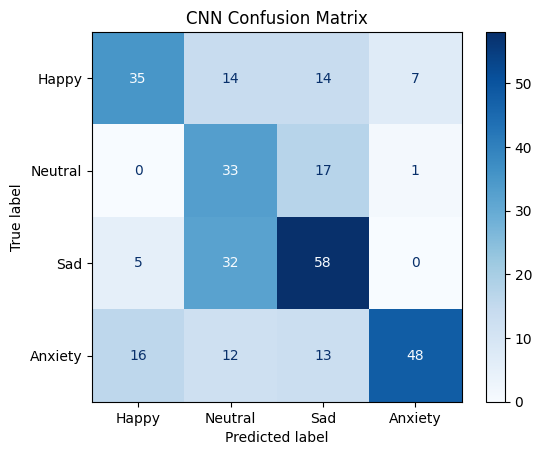

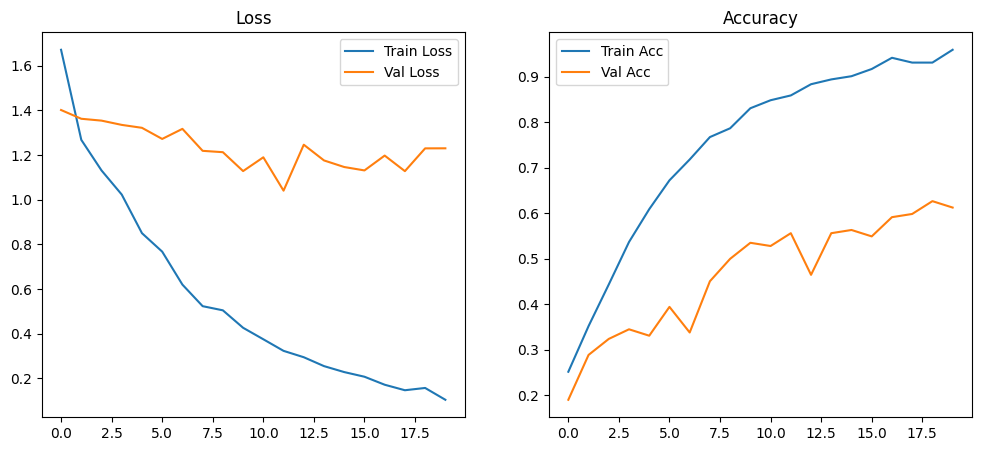

In [3]:
# ===============================
# 0. IMPORTS
# ===============================
import pandas as pd
import numpy as np
import glob
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import mne
from mne.preprocessing import ICA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")
mne.set_log_level('WARNING')

# ===============================
# 1. CONFIGURATION
# ===============================
FOLDER_PATH = '/content/drive/MyDrive/EEG_Data/Final Data/'
EMOTION_LABELS = {'Happy': 0, 'Neutral': 1, 'Sad': 2, 'Anxiety': 3}

TARGET_SENSORS = list(set([
    'F3', 'Fp1', 'AF3', 'FC5',
    'F4', 'Fp2', 'AF4', 'FC6',
    'F8', 'T7', 'T8',
    'O1', 'O2', 'Oz', 'Cz',
    'Fp2', 'Fp1', 'F4', 'Fz', 'C4', 'Pz'
]))

WINDOW_SIZE = 128
STEP_SIZE = 64    # 50% overlap
SAMPLING_RATE = 128

# ===============================
# 2. HELPER FUNCTIONS
# ===============================
def load_csv_with_auto_header(filepath):
    # Try header in row 1
    df = pd.read_csv(filepath, header=1)
    if not any(col.startswith("EEG.") for col in df.columns.astype(str)):
        # Retry with header in row 0
        df = pd.read_csv(filepath, header=0)
    return df

def get_eeg_columns(df):
    eeg_cols = []
    ch_names = []

    for c in df.columns:
        if c.startswith("EEG."):
            ch = c.replace("EEG.", "").strip()
            if ch in TARGET_SENSORS:
                eeg_cols.append(c)
                ch_names.append(ch)

    return eeg_cols, ch_names

def apply_ica(eeg_data, ch_names, sfreq=SAMPLING_RATE):

    # Create MNE Raw object
    info = mne.create_info(
        ch_names=ch_names,
        sfreq=sfreq,
        ch_types=['eeg'] * len(ch_names)
    )
    raw = mne.io.RawArray(eeg_data.T, info)

    # Set montage (important for spatial patterns)
    try:
        montage = mne.channels.make_standard_montage("standard_1020")
        raw.set_montage(montage, match_case=False, on_missing='warn')
    except Exception as e:
        print(f"Warning: Could not set montage: {e}. Continuing without montage.")

    # ICA (fewer components for stability)
    n_components = min(12, len(ch_names) - 1)

    ica = ICA(
        n_components=n_components,
        random_state=42,
        max_iter=500,
        method='fastica'
    )

    ica.fit(raw)

    # Automatic component rejection
    sources = ica.get_sources(raw).get_data()  # (components, samples)
    components_matrix = np.asarray(ica.get_components())

    bad_components = []
    frontal_channels = ['Fp1', 'Fp2', 'AF3', 'AF4', 'F3', 'F4', 'Fz']

    for idx, component in enumerate(sources):
        # Heuristic 1: High kurtosis → blink-like spikes
        kurt = pd.Series(component).kurt()

        # Skip if kurtosis is NaN
        if np.isnan(kurt) or np.isinf(kurt):
            continue

        # Heuristic 2: High frontal dominance
        topo = components_matrix[:, idx]
        # Safe channel index lookup
        frontal_idx = []
        for ch in frontal_channels:
            if ch in ch_names:
                try:
                    frontal_idx.append(ch_names.index(ch))
                except ValueError:
                    continue

        frontal_power = np.mean(np.abs(topo[frontal_idx])) if frontal_idx else 0
        global_power = np.mean(np.abs(topo))

        if global_power == 0:
            continue

        if (kurt > 10) and (frontal_power > global_power * 1.2):
            bad_components.append(idx)

    # Exclude detected artifact components
    ica.exclude = bad_components

    raw_clean = ica.apply(raw.copy())

    print(f"ICA applied: rejected {len(bad_components)} components → {bad_components}")

    return raw_clean.get_data().T

def load_eeg_segments(
    data_file,
    label_name,
    apply_ica_flag=True,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
    sfreq=SAMPLING_RATE
):
    try:
        df = load_csv_with_auto_header(data_file)
    except Exception as e:
        print(f"Failed to load {data_file}: {e}")
        return [], []

    # Extract EEG channels
    eeg_cols, ch_names = get_eeg_columns(df)

    if len(eeg_cols) < 4:
        print(f"Skipped {os.path.basename(data_file)}: only {len(eeg_cols)} EEG channels")
        return [], []

    eeg_data = df[eeg_cols].values  # (samples, channels)

    # ICA (once per recording)
    if apply_ica_flag:
      try:
        eeg_data = apply_ica(eeg_data, ch_names, sfreq)
      except Exception as e:
        print(f"ICA failed on {os.path.basename(data_file)}: {e}")
        return [], []

    # Sliding window segmentation
    X_segments, y_segments = [], []

    n_samples = eeg_data.shape[0]

    for start in range(0, n_samples - window_size + 1, step_size):
        segment = eeg_data[start:start + window_size, :]

        # Z-score normalization per channel
        segment = (segment - np.mean(segment, axis=0)) / (np.std(segment, axis=0) + 1e-6)

        X_segments.append(segment)
        y_segments.append(EMOTION_LABELS[label_name])

    return X_segments, y_segments

# ===============================
# 3. LOAD ALL DATA
# ===============================
X_all, y_all = [], []
loaded_files = set()

data_files = glob.glob(os.path.join(FOLDER_PATH, "*md.bp.csv"))

for data_file in data_files:
    filename = os.path.basename(data_file)
    if filename in loaded_files:
        continue

    label_name = None
    process_file = False

    # 1. HAPPY
    if "Happy" in filename:
        label_name = "Happy"
        process_file = True

    # 2. NEUTRAL
    elif "Neutral" in filename:
        label_name = "Neutral"
        process_file = True

    # 3. SAD
    elif "Sad" in filename:
      label_name = "Sad"
      process_file = True

    # 4. ANXIETY
    elif "Anxiety" in filename:
      label_name = "Anxiety"
      process_file = True

    if not process_file:
        continue

    # Load EEG segments
    X_seg, y_seg = load_eeg_segments(data_file, label_name)

    if len(X_seg) == 0:
        continue  # skip if no segments

    X_all.extend(X_seg)
    y_all.extend(y_seg)
    loaded_files.add(filename)

    #print(f"Loaded {label_name}: {len(X_seg)} segments from {filename}")

# Convert to numpy arrays
X_all = np.array(X_all)
y_all = np.array(y_all)
print(f"\nTotal segments loaded: {len(X_all)}")

# =================================
# 4. TRAIN-TEST SPLIT & BALANCING
# =================================
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=42
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

# ===============================
# 5. CNN MODEL
# ===============================
input_shape = X_train.shape[1:]  # (time_steps, channels)
num_classes = len(EMOTION_LABELS)

model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ===============================
# 6. TRAIN
# ===============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weight_dict,
    verbose=1
)

# ===============================
# 7. EVALUATE
# ===============================
y_pred = np.argmax(model.predict(X_test), axis=1)

results_data = []

# Identify present labels
present_labels = sorted(list(set(y_test) | set(y_pred)))

for label_idx in present_labels:
    label_name = [k for k, v in EMOTION_LABELS.items() if v == label_idx][0]

    # Compute per-class TP, TN, FP, FN
    TP = np.sum((y_test == label_idx) & (y_pred == label_idx))
    TN = np.sum((y_test != label_idx) & (y_pred != label_idx))
    FP = np.sum((y_test != label_idx) & (y_pred == label_idx))
    FN = np.sum((y_test == label_idx) & (y_pred != label_idx))

    # Per-class accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) > 0 else 0
    precision = precision_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)

    results_data.append({
        "Emotion": label_name,
        "Accuracy": round(accuracy, 2),
        "Precision": round(precision, 2),
        "Recall": round(recall, 2),
        "F1-Score": round(f1, 2)
    })

# Create results DataFrame
results_df = pd.DataFrame(results_data).set_index("Emotion")
results_df = results_df[["Accuracy", "Precision", "Recall", "F1-Score"]]
print("\n--- Per-Class Metrics ---")
print(results_df)

# Overall model accuracy
overall_acc = np.mean(y_pred == y_test)
print(f"\nOverall Model Accuracy: {overall_acc:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
display_labels = [k for k, v in EMOTION_LABELS.items() if v in present_labels]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()

# ===============================
# 8. PLOT LOSS/ACCURACY
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()